In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

In [16]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1) (1).zip


In [17]:
import zipfile

with zipfile.ZipFile("archive (1).zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [18]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = (128, 128)

def load_images(folder, label):
    data = []
    labels = []

    for file in os.listdir(folder):
        if file.endswith(("jpg", "png", "jpeg")):
            img = load_img(os.path.join(folder, file), target_size=IMG_SIZE)
            img = img_to_array(img) / 255.0
            data.append(img)
            labels.append(label)

    return data, labels

In [19]:
print(os.listdir("/content"))

['.config', 'yes', 'no', 'brain_tumor_dataset', 'archive (1) (1).zip', 'archive (1).zip', 'sample_data']


In [22]:
yes_data, yes_labels = load_images("/content/yes", 1)
no_data, no_labels = load_images("/content/no", 0)

In [23]:
X = np.array(yes_data + no_data)
y = np.array(yes_labels + no_labels)

In [24]:
print("Total Images:", X.shape)

Total Images: (179, 128, 128, 3)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 932ms/step - accuracy: 0.5245 - loss: 1.0081 - val_accuracy: 0.5000 - val_loss: 0.6670
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5944 - loss: 0.6715 - val_accuracy: 0.7778 - val_loss: 0.5761
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 891ms/step - accuracy: 0.6993 - loss: 0.5979 - val_accuracy: 0.8611 - val_loss: 0.4362
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 973ms/step - accuracy: 0.7063 - loss: 0.5675 - val_accuracy: 0.8333 - val_loss: 0.5197
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 893ms/step - accuracy: 0.7413 - loss: 0.5406 - val_accuracy: 0.8333 - val_loss: 0.4183
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 855ms/step - accuracy: 0.7483 - loss: 0.4941 - val_accuracy: 0.8056 - val_loss: 0.4368
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7902 - loss: 0.4538 - val_accuracy: 0.8056 - val_loss: 0.4193
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 842ms/step - accuracy: 0.7972 - loss: 0.3992 - val_accuracy: 0.8056 - val_loss: 0.413

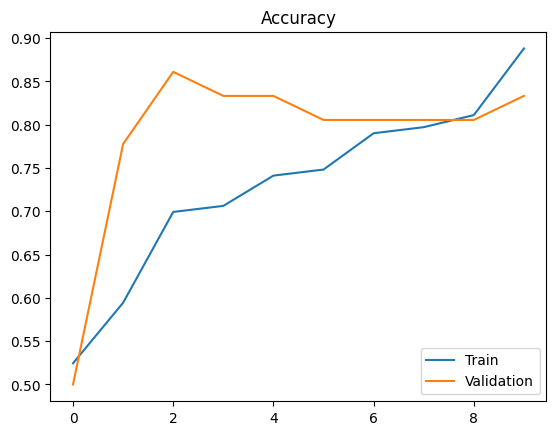

In [28]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")
plt.show()

In [29]:
img = load_img("/content/yes/Y1.jpg", target_size=(128,128))
img = img_to_array(img) / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Tumor Detected 🧠")
else:
    print("No Tumor ✅")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Tumor Detected 🧠
